# Stage 3 — Predictor con escala temporal más rápida

Este control cambia un solo factor respecto del smoke EMA `0.90`: el learning rate del predictor lineal `M` pasa de `1×` a `4×` el learning rate del encoder. Datos, seed, arquitectura, EMA, pérdidas, clipping, duración, checkpoint y gates permanecen congelados.

La pregunta es si `M` estaba siguiendo demasiado lentamente una base latente móvil. Registramos su trayectoria por época, pero el checkpoint sigue seleccionado sólo por mínima validation loss total y test no se construye.

In [1]:
# ruff: noqa: E402, E501, I001
import copy
import json
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import yaml
from IPython.display import Markdown, display

from koopman_jepa.config import DataConfig, ExperimentConfig, ModelConfig, TrainConfig, validate_config
from koopman_jepa.koopman import expected_active_spectrum, match_eigenvalues
from koopman_jepa.model import TemporalJEPA
from koopman_jepa.phase_analysis import evaluate_phase_operator_diagnostics, evaluate_phase_representation
from koopman_jepa.phase_data import PhaseWindowConfig, make_phase_tensor_dataset_splits
from koopman_jepa.training import collect_paired_embeddings, evaluate_model_loss, select_device, set_seed, train_model_with_validation_checkpoint

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
REFERENCE_PATH = ROOT / "configs" / "stage3_cyclic_neural_ema_fast_smoke.yaml"
CONFIG_PATH = ROOT / "configs" / "stage3_cyclic_predictor_fast_smoke.yaml"
with REFERENCE_PATH.open(encoding="utf-8") as handle:
    reference_raw = yaml.safe_load(handle)
with CONFIG_PATH.open(encoding="utf-8") as handle:
    raw = yaml.safe_load(handle)
normalized = copy.deepcopy(raw)
predictor_learning_rate_multiplier = normalized["train"].pop("predictor_learning_rate_multiplier")
assert predictor_learning_rate_multiplier == 4.0
assert normalized == reference_raw

dynamics = raw["dynamics"]
base_seed = int(raw["base_seed"])
emission_config = PhaseWindowConfig(**raw["emission"], repeats_per_transition=1)
model_raw = raw["model"]
experiment_config = ExperimentConfig(
    data=DataConfig(context_length=emission_config.window_length),
    model=ModelConfig(latent_dim=model_raw["latent_dim"], channels=model_raw["channels"], predictor_init=model_raw["predictor_init"]),
    train=TrainConfig(seed=base_seed, **raw["train"]),
)
validate_config(experiment_config)
splits = make_phase_tensor_dataset_splits(
    emission_config,
    train_repeats_per_transition=raw["splits"]["train_repeats_per_transition"],
    validation_repeats_per_transition=raw["splits"]["validation_repeats_per_transition"],
    seed=base_seed,
)
train_dataset = splits.train[dynamics]
validation_dataset = splits.validation[dynamics]
print(json.dumps({"config": CONFIG_PATH.name, "single_factor": "predictor_learning_rate_multiplier=4.0", "checkpoint_metric": raw["selection"]["metric"], "test_constructed": False}, indent=2))

{
  "config": "stage3_cyclic_predictor_fast_smoke.yaml",
  "single_factor": "predictor_learning_rate_multiplier=4.0",
  "checkpoint_metric": "validation_total_loss",
  "test_constructed": false
}


In [3]:
set_seed(base_seed)
device = select_device(experiment_config.train.device)
model = TemporalJEPA(
    latent_dim=model_raw["latent_dim"],
    channels=model_raw["channels"],
    predictor_init=model_raw["predictor_init"],
    pooling=model_raw["pooling"],
    input_length=emission_config.window_length,
).to(device)
baseline = evaluate_model_loss(model, validation_dataset, experiment_config, device)
initial_predictor = model.predictor.matrix.detach().cpu().numpy().copy()
initial_norm = np.linalg.norm(initial_predictor)
expected_spectrum = expected_active_spectrum(dynamics, emission_config.num_phases)

def trace_epoch(epoch, current_model, row):
    current, future_online, future_target, phase_pairs = collect_paired_embeddings(
        current_model, validation_dataset, experiment_config.train.batch_size, device
    )
    matrix = current_model.predictor.matrix.detach().cpu().numpy()
    diagnostics = evaluate_phase_operator_diagnostics(
        current, future_online, future_target, phase_pairs[:, 0], phase_pairs[:, 1], matrix, dynamics
    )
    spectral_match = match_eigenvalues(np.linalg.eigvals(matrix), expected_spectrum)
    return {
        "trace_predictor_relative_movement": float(np.linalg.norm(matrix - initial_predictor) / initial_norm),
        "trace_predictor_spectral_max_error": spectral_match["max_absolute_error"],
        "trace_predictor_online_error": diagnostics["trained_online_endomorphism_error"],
        "trace_predictor_posthoc_distance": diagnostics["predictor_vs_posthoc_online_error"],
        "trace_posthoc_online_spectral_max_error": diagnostics["posthoc_online_spectral_max_error"],
        "trace_online_target_basis_error": diagnostics["online_target_phase_basis_error"],
    }

training_result = train_model_with_validation_checkpoint(
    model, train_dataset, validation_dataset, experiment_config, device, epoch_callback=trace_epoch
)
selected = evaluate_model_loss(model, validation_dataset, experiment_config, device)
history = training_result.history
train_current, _, _, train_phase_pairs = collect_paired_embeddings(model, train_dataset, experiment_config.train.batch_size, device)
validation_current, validation_future_online, validation_future_target, validation_phase_pairs = collect_paired_embeddings(model, validation_dataset, experiment_config.train.batch_size, device)
predictor_matrix = model.predictor.matrix.detach().cpu().numpy()
metrics = evaluate_phase_representation(
    train_current, train_phase_pairs[:, 0], validation_current, validation_phase_pairs[:, 0], predictor_matrix, dynamics, base_seed
)
diagnostics = evaluate_phase_operator_diagnostics(
    validation_current, validation_future_online, validation_future_target, validation_phase_pairs[:, 0], validation_phase_pairs[:, 1], predictor_matrix, dynamics
)

epoch=001 train=3.500343 val=2.131928


epoch=006 train=1.010721 val=2.179607


epoch=012 train=0.651345 val=2.720424


epoch=018 train=1.158038 val=17.054657


epoch=024 train=1.307587 val=29.845873


epoch=030 train=0.661532 val=21.130027


In [4]:
validation_loss_ratio = selected.loss / baseline.loss
history_is_finite = all(np.isfinite(value) for row in history for value in row.values())
gate_config = raw["gates"]
gate_checks = {
    "finite_training": history_is_finite,
    "validation_improves": validation_loss_ratio <= gate_config["maximum_validation_loss_ratio"],
    "embedding_scale": metrics["embedding_std_mean"] >= gate_config["minimum_embedding_std_mean"],
    "effective_rank": metrics["effective_rank"] >= gate_config["minimum_effective_rank"],
    "phase_probe": metrics["linear_probe_accuracy"] >= gate_config["minimum_linear_probe_accuracy"],
    "phase_alignment": metrics["phase_alignment_error"] <= gate_config["maximum_phase_alignment_error"],
    "active_rank": metrics["active_rank"] == gate_config["required_active_rank"],
    "intertwining": metrics["intertwining_error"] <= gate_config["maximum_intertwining_error"],
    "active_invariance": metrics["active_invariance_error"] is not None and metrics["active_invariance_error"] <= gate_config["maximum_active_invariance_error"],
    "spectrum": metrics["spectral_max_absolute_error"] is not None and metrics["spectral_max_absolute_error"] <= gate_config["maximum_spectral_error"],
}
predictor_fast_gate_passed = bool(all(gate_checks.values()))
best_spectral_index = int(np.argmin([row["trace_predictor_spectral_max_error"] for row in history]))
best_posthoc_index = int(np.argmin([row["trace_posthoc_online_spectral_max_error"] for row in history]))
ever_passed_spectrum = bool(history[best_spectral_index]["trace_predictor_spectral_max_error"] <= gate_config["maximum_spectral_error"])
validation_metric_names = ["val_loss", "val_prediction_loss", "val_mean_loss", "val_variance_loss", "val_covariance_loss"]
validation_minimum_indices = {name: int(np.argmin([row[name] for row in history])) for name in validation_metric_names}
selection_diagnostic = {
    name: {
        "epoch": index + 1,
        "value": history[index][name],
        "predictor_spectral_error": history[index]["trace_predictor_spectral_max_error"],
        "predictor_online_error": history[index]["trace_predictor_online_error"],
    }
    for name, index in validation_minimum_indices.items()
}
summary = {
    "selected_epoch": training_result.best_epoch,
    "validation_loss_ratio": float(validation_loss_ratio),
    "effective_rank": metrics["effective_rank"],
    "linear_probe_accuracy": metrics["linear_probe_accuracy"],
    "phase_alignment_error": metrics["phase_alignment_error"],
    "intertwining_error": metrics["intertwining_error"],
    "spectral_max_absolute_error": metrics["spectral_max_absolute_error"],
    "online_target_phase_basis_error": diagnostics["online_target_phase_basis_error"],
    "posthoc_online_spectral_max_error": diagnostics["posthoc_online_spectral_max_error"],
    "best_trace_spectral_epoch": best_spectral_index + 1,
    "best_trace_spectral_error": history[best_spectral_index]["trace_predictor_spectral_max_error"],
    "best_trace_predictor_online_error": history[best_spectral_index]["trace_predictor_online_error"],
    "predictor_ever_passed_spectrum": ever_passed_spectrum,
    "best_trace_posthoc_error": history[best_posthoc_index]["trace_posthoc_online_spectral_max_error"],
    "maximum_predictor_relative_movement": max(row["trace_predictor_relative_movement"] for row in history),
    "predictor_fast_gate_passed": predictor_fast_gate_passed,
    "selection_diagnostic": selection_diagnostic,
}
print(json.dumps({**summary, "gate_checks": gate_checks}, indent=2))

{
  "selected_epoch": 3,
  "validation_loss_ratio": 0.44281182292093013,
  "effective_rank": 2.9314755102885246,
  "linear_probe_accuracy": 1.0,
  "phase_alignment_error": 0.15168592302659792,
  "intertwining_error": 1.1416231344383185,
  "spectral_max_absolute_error": 1.0818945844888745,
  "online_target_phase_basis_error": 0.22000337154938,
  "posthoc_online_spectral_max_error": 0.03633658982309155,
  "best_trace_spectral_epoch": 30,
  "best_trace_spectral_error": 0.04535271957022435,
  "best_trace_predictor_online_error": 0.045100050040543974,
  "predictor_ever_passed_spectrum": true,
  "best_trace_posthoc_error": 0.02911764410960293,
  "maximum_predictor_relative_movement": 1.0956159830093384,
  "predictor_fast_gate_passed": false,
  "selection_diagnostic": {
    "val_loss": {
      "epoch": 3,
      "value": 2.0377643704414368,
      "predictor_spectral_error": 1.0818945817143393,
      "predictor_online_error": 1.1404636246984161
    },
    "val_prediction_loss": {
      "epoch":

/Users/micolmichanie/Documents/koopman-jepa/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


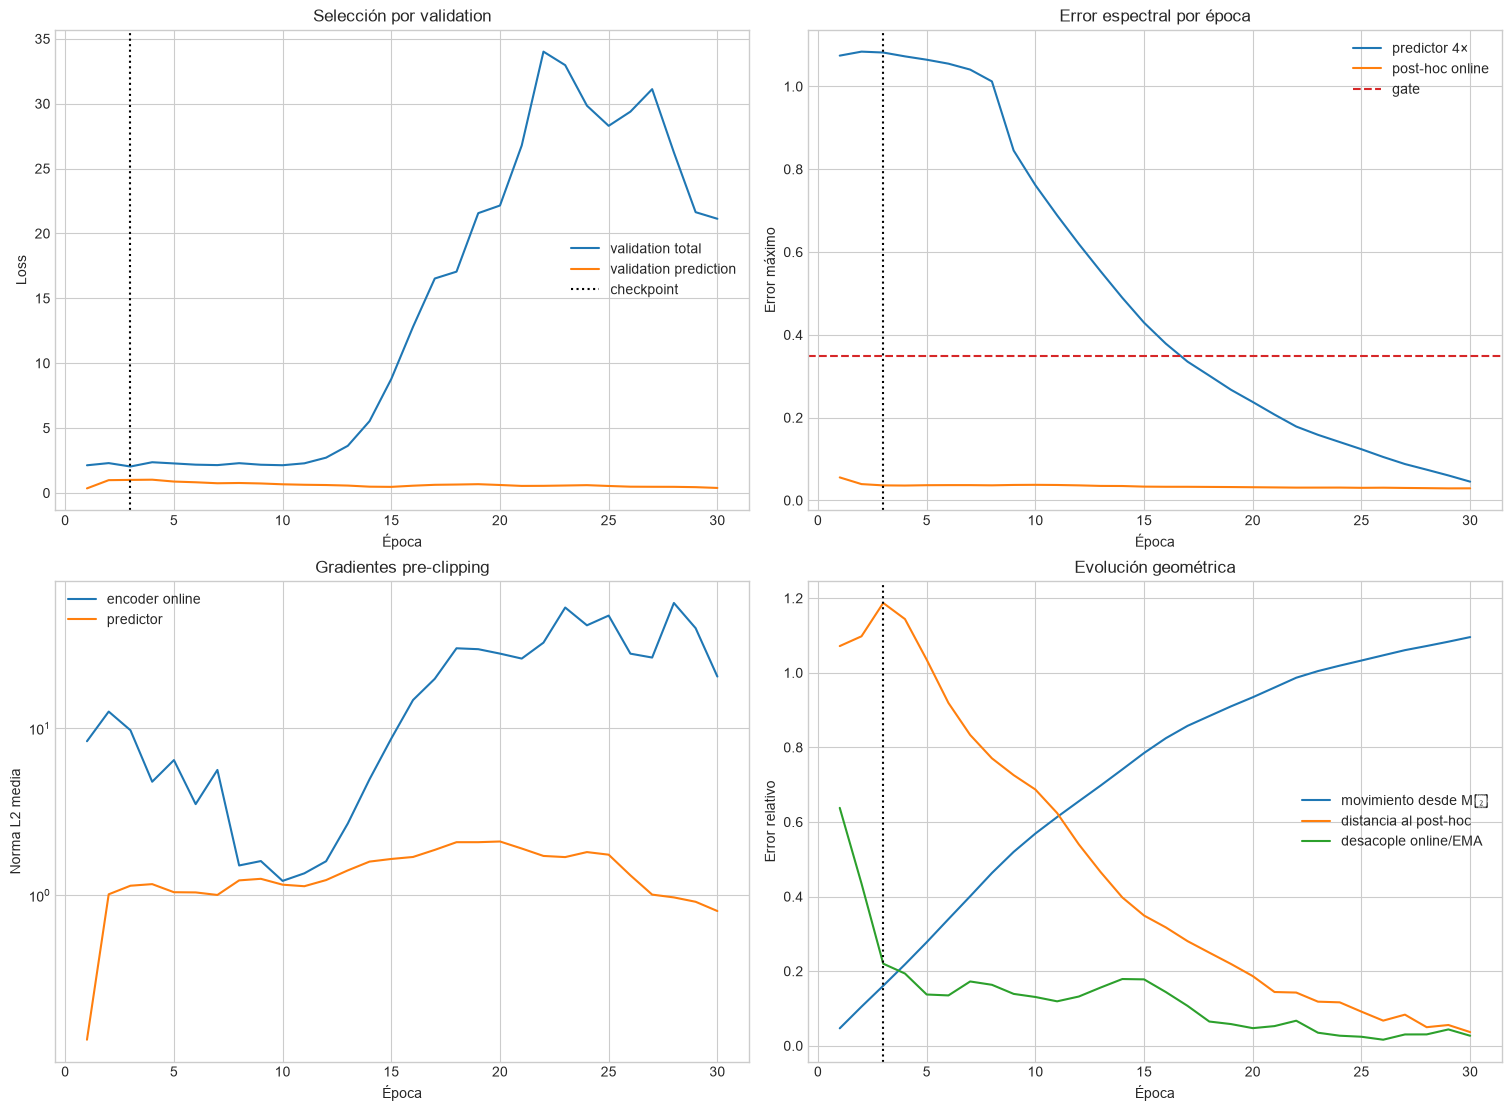

## Análisis del resultado

- Gate cíclico con predictor `4×`: **FAIL**.
- Checkpoint: época **3**; ratio validation/baseline: **0.443**.
- Rango efectivo / probe de fase: **2.931 / 100.00%**.
- Error de alineación / entrelazamiento: **0.152 / 1.142**.
- Error espectral del predictor seleccionado: **1.082** (referencia `1×`: `1.059`).
- Mejor error espectral del predictor durante entrenamiento: **0.045**, época **30**.
- Error de endomorfismo online en esa época: **0.045**.
- Mínimo de validation prediction loss: época **1**, con error espectral **1.074**.
- Diferencia de base online/EMA: **0.220**.
- Error espectral post-hoc online: **0.036**.

El predictor 4× sí cruza el gate espectral durante el entrenamiento, pero el checkpoint de mínima validation loss selecciona una época anterior. La velocidad de M era relevante; el objetivo de selección no preserva ese estado.

La comparación causal válida es contra EMA `0.90` con predictor `1×`: sólo cambia la tasa de `M`. Es una sola seed de desarrollo, y test no se construye.


In [5]:
epochs = np.arange(1, len(history) + 1)
fig, axes = plt.subplots(2, 2, figsize=(15, 11), constrained_layout=True)
axes[0, 0].plot(epochs, [row["val_loss"] for row in history], label="validation total")
axes[0, 0].plot(epochs, [row["val_prediction_loss"] for row in history], label="validation prediction")
axes[0, 0].axvline(training_result.best_epoch, color="black", linestyle=":", label="checkpoint")
axes[0, 0].set(title="Selección por validation", xlabel="Época", ylabel="Loss")
axes[0, 0].legend()

axes[0, 1].plot(epochs, [row["trace_predictor_spectral_max_error"] for row in history], label="predictor 4×")
axes[0, 1].plot(epochs, [row["trace_posthoc_online_spectral_max_error"] for row in history], label="post-hoc online")
axes[0, 1].axhline(gate_config["maximum_spectral_error"], color="tab:red", linestyle="--", label="gate")
axes[0, 1].axvline(training_result.best_epoch, color="black", linestyle=":")
axes[0, 1].set(title="Error espectral por época", xlabel="Época", ylabel="Error máximo")
axes[0, 1].legend()

axes[1, 0].semilogy(epochs, [row["train_online_gradient_norm"] for row in history], label="encoder online")
axes[1, 0].semilogy(epochs, [row["train_predictor_gradient_norm"] for row in history], label="predictor")
axes[1, 0].set(title="Gradientes pre-clipping", xlabel="Época", ylabel="Norma L2 media")
axes[1, 0].legend()

axes[1, 1].plot(epochs, [row["trace_predictor_relative_movement"] for row in history], label="movimiento desde M₀")
axes[1, 1].plot(epochs, [row["trace_predictor_posthoc_distance"] for row in history], label="distancia al post-hoc")
axes[1, 1].plot(epochs, [row["trace_online_target_basis_error"] for row in history], label="desacople online/EMA")
axes[1, 1].axvline(training_result.best_epoch, color="black", linestyle=":")
axes[1, 1].set(title="Evolución geométrica", xlabel="Época", ylabel="Error relativo")
axes[1, 1].legend()
plt.show()

spectral_reading = (
    "El predictor 4× sí cruza el gate espectral durante el entrenamiento, pero el checkpoint de mínima validation loss selecciona una época anterior. La velocidad de M era relevante; el objetivo de selección no preserva ese estado."
    if ever_passed_spectrum and not gate_checks["spectrum"]
    else (
        "El predictor seleccionado cruza el gate espectral."
        if gate_checks["spectrum"]
        else "El predictor 4× nunca cruza el gate espectral; acelerarlo no es suficiente."
    )
)
display(Markdown(f"""## Análisis del resultado

- Gate cíclico con predictor `4×`: **{'PASS' if predictor_fast_gate_passed else 'FAIL'}**.
- Checkpoint: época **{training_result.best_epoch}**; ratio validation/baseline: **{validation_loss_ratio:.3f}**.
- Rango efectivo / probe de fase: **{metrics['effective_rank']:.3f} / {metrics['linear_probe_accuracy']:.2%}**.
- Error de alineación / entrelazamiento: **{metrics['phase_alignment_error']:.3f} / {metrics['intertwining_error']:.3f}**.
- Error espectral del predictor seleccionado: **{metrics['spectral_max_absolute_error']:.3f}** (referencia `1×`: `1.059`).
- Mejor error espectral del predictor durante entrenamiento: **{history[best_spectral_index]['trace_predictor_spectral_max_error']:.3f}**, época **{best_spectral_index + 1}**.
- Error de endomorfismo online en esa época: **{history[best_spectral_index]['trace_predictor_online_error']:.3f}**.
- Mínimo de validation prediction loss: época **{selection_diagnostic['val_prediction_loss']['epoch']}**, con error espectral **{selection_diagnostic['val_prediction_loss']['predictor_spectral_error']:.3f}**.
- Diferencia de base online/EMA: **{diagnostics['online_target_phase_basis_error']:.3f}**.
- Error espectral post-hoc online: **{diagnostics['posthoc_online_spectral_max_error']:.3f}**.

{spectral_reading}

La comparación causal válida es contra EMA `0.90` con predictor `1×`: sólo cambia la tasa de `M`. Es una sola seed de desarrollo, y test no se construye.
"""))

In [6]:
assert predictor_fast_gate_passed

AssertionError: 